In [1]:
# Pipeline configuration — centralizing settings
CONFIG = {
    "input_file": "/content/Super Store Dataset.csv",
    "db_name": "retail_warehouse.db",
    "encoding": "latin1"
}

import pandas as pd

df = pd.read_csv(CONFIG["input_file"], encoding=CONFIG["encoding"])
print(df.shape)
print(df.columns.tolist())
df.head()

(51290, 24)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [2]:
# Convert date columns to actual datetime objects
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Check for nulls
print(df.isnull().sum())

# Check for duplicate rows
print("Duplicates:", df.duplicated().sum())

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64
Duplicates: 0


In [3]:
# Build product dimension with guaranteed unique Product IDs
dim_products = df.sort_values("Order Date") \
                 [["Product ID", "Category", "Sub-Category", "Product Name"]] \
                 .drop_duplicates(subset="Product ID", keep="last")

# Safety check: enforce uniqueness
assert dim_products["Product ID"].is_unique, "Duplicate Product IDs found in dim_products"

print(dim_products.shape)
dim_products.head()

(10292, 4)


,Product ID,Category,Sub-Category,Product Name
25081,FUR-CH-10000666,Furniture,Chairs,"SAFCO Chairmat, Black"
3973,FUR-CHR-10004803,Furniture,Tables,"Chromcraft Wood Table, Fully Assembled"
27994,OFF-AP-10000569,Office Supplies,Appliances,"KitchenAid Coffee Grinder, Black"
14103,FUR-TA-10001693,Furniture,Tables,"Bevis Training Table, with Bottom Storage"
10276,TEC-MA-10000560,Technology,Machines,"StarTech Inkjet, Wireless"


In [4]:
print("Rows in dim_products:", dim_products.shape[0])
print("Unique Product IDs in dim_products:", dim_products["Product ID"].nunique())

Rows in dim_products: 10292
Unique Product IDs in dim_products: 10292


In [5]:
dupes = dim_products[dim_products["Product ID"].duplicated(keep=False)]
print(dupes.shape)
dupes.head(20)

(0, 4)


,Product ID,Category,Sub-Category,Product Name


In [6]:
dim_customers = df[["Customer ID", "Customer Name", "Segment", "City", "State", "Country", "Market", "Region"]].drop_duplicates()
print(dim_customers.shape)
dim_customers.head()

(24959, 8)


,Customer ID,Customer Name,Segment,City,State,Country,Market,Region
0,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,US,East
1,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,APAC,Oceania
2,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,APAC,Oceania
3,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,EU,Central
4,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal,Africa,Africa


In [7]:
print("Unique Customer IDs:", df["Customer ID"].nunique())
print("Rows in dim_customers:", dim_customers.shape[0])

Unique Customer IDs: 1590
Rows in dim_customers: 24959


In [8]:
# Sort by Order Date so the most recent order for each customer comes last
df_sorted = df.sort_values("Order Date")

# Keep only the LAST (most recent) row for each Customer ID
dim_customers = df_sorted[["Customer ID", "Customer Name", "Segment", "City", "State", "Country", "Market", "Region"]].drop_duplicates(subset="Customer ID", keep="last")

print(dim_customers.shape)
dim_customers.head()

(1590, 8)


,Customer ID,Customer Name,Segment,City,State,Country,Market,Region
31956,DK-2985,Darren Koutras,Consumer,Kano,Kano,Nigeria,Africa,Africa
45385,DW-3195,David Wiener,Corporate,Shahriar,Tehran,Iran,EMEA,EMEA
47590,SZ-10035,Sam Zeldin,Home Office,Baraki,Tipaza,Algeria,Africa,Africa
5073,KD-6270,Karen Daniels,Consumer,Izmir,Izmir,Turkey,EMEA,EMEA
14427,CT-1995,Carol Triggs,Consumer,Donets'k,Donetsk,Ukraine,EMEA,EMEA


In [9]:
# Data Dimension
#Get all unique order dates
dim_date = pd.DataFrame({"date": df["Order Date"].unique()})
dim_date = dim_date.sort_values("date").reset_index(drop=True)

# Derive useful fields from the date
dim_date["date_id"] = dim_date.index + 1  # simple numeric ID: 1, 2, 3...
dim_date["year"] = dim_date["date"].dt.year
dim_date["month"] = dim_date["date"].dt.month
dim_date["quarter"] = dim_date["date"].dt.quarter

print(dim_date.shape)
dim_date.head()

(1430, 5)


,date,date_id,year,month,quarter
0,2011-01-01,1,2011,1,1
1,2011-01-02,2,2011,1,1
2,2011-01-03,3,2011,1,1
3,2011-01-04,4,2011,1,1
4,2011-01-05,5,2011,1,1


In [10]:
# Merge the original data with dim_date to get the date_id for each order
fact_sales = df.merge(dim_date[["date", "date_id"]], left_on="Order Date", right_on="date", how="left")

# Select just the columns needed for the fact table
fact_sales = fact_sales[[
    "Order ID", "Customer ID", "Product ID", "date_id",
    "Sales", "Quantity", "Discount", "Profit", "Shipping Cost", "Order Priority"
]]

print(fact_sales.shape)
fact_sales.head()

(51290, 10)


,Order ID,Customer ID,Product ID,date_id,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,CA-2012-124891,RH-19495,TEC-AC-10003033,556,2309.650,7,0.0,762.1845,933.57,Critical
1,IN-2013-77878,JR-16210,FUR-CH-10003950,745,3709.395,9,0.1,-288.7650,923.63,Critical
2,IN-2013-71249,CR-12730,TEC-PH-10004664,995,5175.171,9,0.1,919.9710,915.49,Medium
3,ES-2013-1579342,KM-16375,TEC-PH-10004583,737,2892.510,5,0.1,-96.5400,910.16,Medium
4,SG-2013-4320,RH-9495,TEC-SHA-10000501,1013,2832.960,8,0.0,311.5200,903.04,Critical


In [11]:
# Check that every foreign key in fact_sales actually exists in its dimension table

missing_products = set(fact_sales["Product ID"]) - set(dim_products["Product ID"])
missing_customers = set(fact_sales["Customer ID"]) - set(dim_customers["Customer ID"])
missing_dates = set(fact_sales["date_id"]) - set(dim_date["date_id"])

print("Missing product references:", len(missing_products))
print("Missing customer references:", len(missing_customers))
print("Missing date references:", len(missing_dates))

Missing product references: 0
Missing customer references: 0
Missing date references: 0


In [12]:
# Enforce data quality: halt the pipeline if integrity checks fail

assert len(missing_products) == 0, f"Data quality failure: {len(missing_products)} orphaned product references"
assert len(missing_customers) == 0, f"Data quality failure: {len(missing_customers)} orphaned customer references"
assert len(missing_dates) == 0, f"Data quality failure: {len(missing_dates)} orphaned date references"
assert (fact_sales["Sales"] >= 0).all(), "Data quality failure: negative sales values found"
assert (fact_sales["Quantity"] > 0).all(), "Data quality failure: non-positive quantity found"
assert fact_sales["Discount"].between(0, 1).all(), "Data quality failure: discount out of [0,1] range"

print("All data quality checks passed")

All data quality checks passed


In [13]:
name_to_id_counts = dim_products.groupby("Product Name")["Product ID"].nunique()
inconsistent_names = name_to_id_counts[name_to_id_counts > 1]

print("Product names with multiple IDs:", len(inconsistent_names))
inconsistent_names.head(10)

Product names with multiple IDs: 1941


,Product ID
Product Name,
"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",2
"Acco 3-Hole Punch, Clear",4
"Acco 3-Hole Punch, Durable",4
"Acco 3-Hole Punch, Economy",5
"Acco 3-Hole Punch, Recycled",4
"Acco Binder Covers, Clear",3
"Acco Binder Covers, Durable",4
"Acco Binder Covers, Economy",5
"Acco Binder Covers, Recycled",5


In [14]:
# Quantify the master data inconsistency: how many product names have inconsistent Product IDs across the dataset

print(f"Total unique Product IDs: {dim_products['Product ID'].nunique()}")
print(f"Total unique Product Names: {dim_products['Product Name'].nunique()}")
print(f"Product names with inconsistent IDs: {len(inconsistent_names)}")

Total unique Product IDs: 10292
Total unique Product Names: 3685
Product names with inconsistent IDs: 1941


In [15]:
import logging

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s", force=True)
logger = logging.getLogger()

def extract(filepath=None):
    filepath = filepath or CONFIG["input_file"]
    try:
        df = pd.read_csv(filepath, encoding=CONFIG["encoding"])
        logger.info(f"Extracted {df.shape[0]} rows from {filepath}")
        return df
    except Exception as e:
        logger.error(f"Extraction failed: {e}")
        raise

def transform(df):
    """Clean and prepare the raw data."""
    df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
    df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)
    logger.info("Transformed date columns")
    return df

def build_dim_products(df):
    dim = (
        df.sort_values("Order Date")
          [["Product ID", "Category", "Sub-Category", "Product Name"]]
          .drop_duplicates(subset="Product ID", keep="last")
    )
    assert dim["Product ID"].is_unique, "Duplicate Product IDs found in dim_products"
    logger.info(f"Built dim_products with {dim.shape[0]} rows")
    return dim

def build_dim_customers(df):
    df_sorted = df.sort_values("Order Date")
    dim = df_sorted[["Customer ID", "Customer Name", "Segment", "City", "State", "Country", "Market", "Region"]].drop_duplicates(subset="Customer ID", keep="last")
    assert dim["Customer ID"].is_unique, "Duplicate Customer IDs found in dim_customers"
    logger.info(f"Built dim_customers with {dim.shape[0]} rows")
    return dim

def build_dim_date(df):
    dim = pd.DataFrame({"date": df["Order Date"].unique()}).sort_values("date").reset_index(drop=True)
    dim["date_id"] = dim.index + 1
    dim["year"] = dim["date"].dt.year
    dim["month"] = dim["date"].dt.month
    dim["quarter"] = dim["date"].dt.quarter
    logger.info(f"Built dim_date with {dim.shape[0]} rows")
    return dim

def build_fact_sales(df, dim_date):
    fact = df.merge(dim_date[["date", "date_id"]], left_on="Order Date", right_on="date", how="left")
    fact = fact[["Order ID", "Customer ID", "Product ID", "date_id", "Sales", "Quantity", "Discount", "Profit", "Shipping Cost", "Order Priority"]]
    logger.info(f"Built fact_sales with {fact.shape[0]} rows")
    return fact

def load_to_sqlite(tables: dict, db_name=None):
    """Load a dict of {table_name: dataframe} into SQLite."""
    db_name = db_name or CONFIG["db_name"]
    conn = sqlite3.connect(db_name)
    for name, table in tables.items():
        table.to_sql(name, conn, if_exists="replace", index=False)
        logger.info(f"Loaded table '{name}' ({table.shape[0]} rows) into {db_name}")
    return conn

In [16]:
import sqlite3
raw_df = extract()
clean_df = transform(raw_df)
dim_products = build_dim_products(clean_df)
dim_customers = build_dim_customers(clean_df)
dim_date = build_dim_date(clean_df)
fact_sales = build_fact_sales(clean_df, dim_date)
conn = load_to_sqlite({
    "dim_products": dim_products,
    "dim_customers": dim_customers,
    "dim_date": dim_date,
    "fact_sales": fact_sales
})

2026-09-01 15:19:03,976 - INFO - Extracted 51290 rows from /content/Super Store Dataset.csv
2026-09-01 15:19:04,233 - INFO - Transformed date columns
2026-09-01 15:19:04,272 - INFO - Built dim_products with 10292 rows
2026-09-01 15:19:04,308 - INFO - Built dim_customers with 1590 rows
2026-09-01 15:19:04,316 - INFO - Built dim_date with 1430 rows
2026-09-01 15:19:04,353 - INFO - Built fact_sales with 51290 rows
2026-09-01 15:19:04,419 - INFO - Loaded table 'dim_products' (10292 rows) into retail_warehouse.db
2026-09-01 15:19:04,457 - INFO - Loaded table 'dim_customers' (1590 rows) into retail_warehouse.db
2026-09-01 15:19:04,492 - INFO - Loaded table 'dim_date' (1430 rows) into retail_warehouse.db
2026-09-01 15:19:04,810 - INFO - Loaded table 'fact_sales' (51290 rows) into retail_warehouse.db


In [17]:
# Simulate incremental loading: split data into "historical" and "new" batches, then demonstrate loading only the new batch without reprocessing everything

def load_incremental(new_data_df, dim_date, db_name=None):
    """Append only new fact_sales rows to the existing database, without reloading everything."""
    db_name = db_name or CONFIG["db_name"]
    conn = sqlite3.connect(db_name)
    new_fact = build_fact_sales(new_data_df, dim_date)
    new_fact.to_sql("fact_sales", conn, if_exists="append", index=False)
    logger.info(f"Incrementally loaded {new_fact.shape[0]} new rows into fact_sales")
    return conn

# Simulate: treat 2014 data as "new" data arriving after initial load
historical_data = clean_df[clean_df["Order Date"].dt.year < 2014]
new_data = clean_df[clean_df["Order Date"].dt.year == 2014]

print(f"Historical: {historical_data.shape[0]} rows, New: {new_data.shape[0]} rows")

Historical: 33759 rows, New: 17531 rows


In [18]:
def load_incremental(new_data_df, full_df, db_name=None):
    """Append new fact_sales rows, first refreshing dimensions with any new members."""
    db_name = db_name or CONFIG["db_name"]
    conn = sqlite3.connect(db_name)

    # Rebuild dims from the FULL dataset (historical + new) so new customers/products/dates aren't missing foreign keys
    dim_products = build_dim_products(full_df)
    dim_customers = build_dim_customers(full_df)
    dim_date = build_dim_date(full_df)

    dim_products.to_sql("dim_products", conn, if_exists="replace", index=False)
    dim_customers.to_sql("dim_customers", conn, if_exists="replace", index=False)
    dim_date.to_sql("dim_date", conn, if_exists="replace", index=False)

    new_fact = build_fact_sales(new_data_df, dim_date)
    new_fact.to_sql("fact_sales", conn, if_exists="append", index=False)
    logger.info(f"Incrementally loaded {new_fact.shape[0]} new rows into fact_sales")

    # Re-verify integrity after the incremental load
    all_products = pd.read_sql("SELECT DISTINCT `Product ID` FROM fact_sales", conn)
    all_customers = pd.read_sql("SELECT DISTINCT `Customer ID` FROM fact_sales", conn)
    missing_p = set(all_products["Product ID"]) - set(dim_products["Product ID"])
    missing_c = set(all_customers["Customer ID"]) - set(dim_customers["Customer ID"])
    assert len(missing_p) == 0, f"Post-load integrity failure: {len(missing_p)} orphaned products"
    assert len(missing_c) == 0, f"Post-load integrity failure: {len(missing_c)} orphaned customers"
    logger.info("Post-incremental-load integrity checks passed")

    return conn

In [19]:
dim_products = build_dim_products(historical_data)
dim_customers = build_dim_customers(historical_data)
dim_date = build_dim_date(historical_data)
fact_sales = build_fact_sales(historical_data, dim_date)
conn = load_to_sqlite({
    "dim_products": dim_products,
    "dim_customers": dim_customers,
    "dim_date": dim_date,
    "fact_sales": fact_sales
})
result = pd.read_sql("SELECT COUNT(*) as total_rows FROM fact_sales", conn)
print("Rows before incremental load:", result["total_rows"][0])

2026-09-01 15:19:04,886 - INFO - Built dim_products with 9584 rows
2026-09-01 15:19:04,916 - INFO - Built dim_customers with 1575 rows
2026-09-01 15:19:04,926 - INFO - Built dim_date with 1069 rows
2026-09-01 15:19:04,946 - INFO - Built fact_sales with 33759 rows
2026-09-01 15:19:05,013 - INFO - Loaded table 'dim_products' (9584 rows) into retail_warehouse.db
2026-09-01 15:19:05,048 - INFO - Loaded table 'dim_customers' (1575 rows) into retail_warehouse.db
2026-09-01 15:19:05,077 - INFO - Loaded table 'dim_date' (1069 rows) into retail_warehouse.db
2026-09-01 15:19:05,308 - INFO - Loaded table 'fact_sales' (33759 rows) into retail_warehouse.db


Rows before incremental load: 33759


In [20]:
# Simulate new data arriving — load ONLY 2014 data incrementally, without reloading historical data

conn = load_incremental(new_data, clean_df)   # pass the full dataset

# Verify: fact_sales should now contain both historical + new rows
result = pd.read_sql("SELECT COUNT(*) as total_rows FROM fact_sales", conn)
print(result)

2026-09-01 15:19:05,357 - INFO - Built dim_products with 10292 rows
2026-09-01 15:19:05,393 - INFO - Built dim_customers with 1590 rows
2026-09-01 15:19:05,401 - INFO - Built dim_date with 1430 rows
2026-09-01 15:19:05,552 - INFO - Built fact_sales with 17531 rows
2026-09-01 15:19:05,646 - INFO - Incrementally loaded 17531 new rows into fact_sales
2026-09-01 15:19:05,726 - INFO - Post-incremental-load integrity checks passed


   total_rows
0       51290


In [21]:
# Total sales, profit, and order count by product category

query1 = """
SELECT p.Category,
       ROUND(SUM(f.Sales), 2) as total_sales,
       ROUND(SUM(f.Profit), 2) as total_profit,
       COUNT(*) as num_orders
FROM fact_sales f
JOIN dim_products p ON f."Product ID" = p."Product ID"
GROUP BY p.Category
ORDER BY total_sales DESC
"""
result1 = pd.read_sql(query1, conn)
print(result1)

          Category  total_sales  total_profit  num_orders
0       Technology   4744557.50     663778.73       10141
1        Furniture   4110874.19     285204.72        9876
2  Office Supplies   3787070.23     518473.83       31273


In [22]:
#Top 10 customers by total sales

query2 = """
SELECT c."Customer Name",
       ROUND(SUM(f.Sales), 2) as total_sales,
       COUNT(*) as num_orders
FROM fact_sales f
JOIN dim_customers c ON f."Customer ID" = c."Customer ID"
GROUP BY c."Customer Name"
ORDER BY total_sales DESC
LIMIT 10
"""
result2 = pd.read_sql(query2, conn)
print(result2)

        Customer Name  total_sales  num_orders
0        Tom Ashbrook     40488.07          80
1        Tamara Chand     37457.33          88
2           Greg Tran     35550.95          87
3  Christopher Conant     35187.08          73
4         Sean Miller     35170.93          50
5        Bart Watters     32310.45          96
6    Natalie Fritzler     31781.26          95
7        Fred Hopkins     30400.67          82
8           Jane Waco     30288.45          75
9        Hunter Lopez     30243.57          53


In [23]:
# Total sales by year and quarter

query3 = """
SELECT d.year,
       d.quarter,
       ROUND(SUM(f.Sales), 2) as total_sales
FROM fact_sales f
JOIN dim_date d ON f.date_id = d.date_id
GROUP BY d.year, d.quarter
ORDER BY d.year, d.quarter
"""
result3 = pd.read_sql(query3, conn)
print(result3)

    year  quarter  total_sales
0   2011        1    335780.01
1   2011        2    478870.98
2   2011        3    613306.37
3   2011        4    831493.54
4   2012        1    399367.71
5   2012        2    625592.86
6   2012        3    737768.89
7   2012        4    914709.23
8   2013        1    565019.59
9   2013        2    834839.49
10  2013        3    933036.99
11  2013        4   1072850.38
12  2014        1    689206.68
13  2014        2    932986.97
14  2014        3   1196482.87
15  2014        4   1481189.35


In [24]:
# Total sales and profit by region

query4 = """
SELECT c.Region,
       ROUND(SUM(f.Sales), 2) as total_sales,
       ROUND(SUM(f.Profit), 2) as total_profit,
       COUNT(*) as num_orders
FROM fact_sales f
JOIN dim_customers c ON f."Customer ID" = c."Customer ID"
GROUP BY c.Region
ORDER BY total_sales DESC
"""
result4 = pd.read_sql(query4, conn)
print(result4)

            Region  total_sales  total_profit  num_orders
0          Central   3058115.77     360818.91       11580
1            South   1752161.40     201796.76        6603
2            North   1363628.87     161195.90        5205
3          Oceania   1007758.11     134304.65        3647
4   Southeast Asia    899331.90     110033.05        3443
5             EMEA    840421.41      75289.86        5190
6             West    839748.67      93730.95        3045
7             East    839604.59     109714.05        3155
8           Africa    756096.51      69383.43        4446
9       North Asia    485203.64      60541.48        1834
10    Central Asia    402043.72      51836.95        1430
11       Caribbean    338214.48      32599.41        1353
12          Canada     60172.83       6211.89         359


In [25]:
# Average order value and profit margin by customer segment

query5 = """
SELECT c.Segment,
       ROUND(AVG(f.Sales), 2) as avg_order_value,
       ROUND(SUM(f.Profit) * 100.0 / SUM(f.Sales), 2) as profit_margin_pct,
       COUNT(*) as num_orders
FROM fact_sales f
JOIN dim_customers c ON f."Customer ID" = c."Customer ID"
GROUP BY c.Segment
ORDER BY avg_order_value DESC
"""
result5 = pd.read_sql(query5, conn)
print(result5)

       Segment  avg_order_value  profit_margin_pct  num_orders
0    Corporate           247.89              11.54       15429
1  Home Office           247.23              11.99        9343
2     Consumer           245.42              11.51       26518


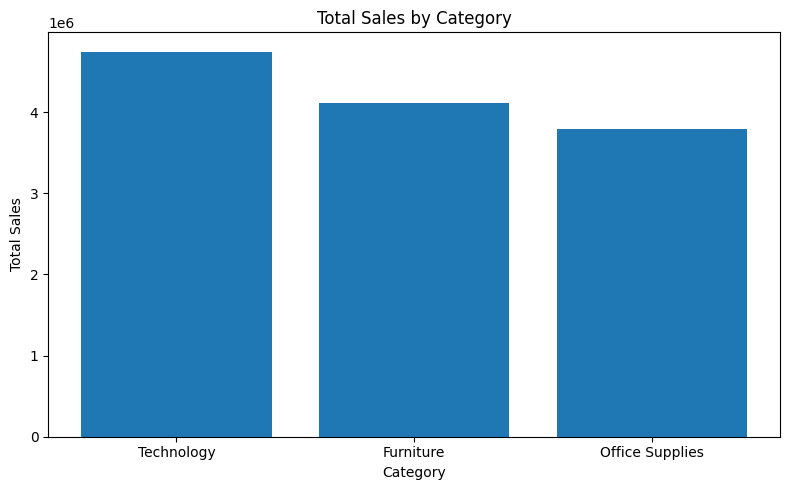

In [26]:
import matplotlib.pyplot as plt

# Chart 1: Revenue by category
plt.figure(figsize=(8, 5))
plt.bar(result1["Category"], result1["total_sales"])
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.savefig("sales_by_category.png")
plt.show()

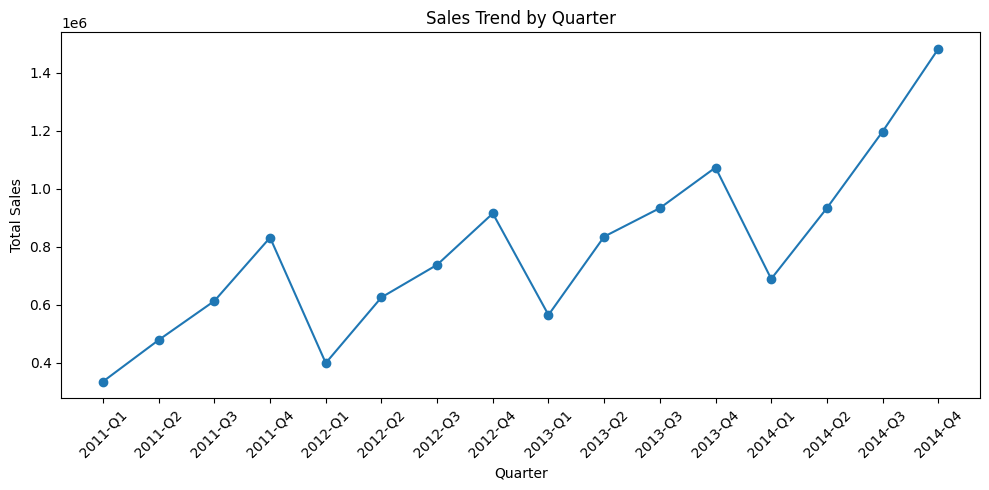

In [27]:
# Chart 2: Sales trend by quarter over time
result3["period"] = result3["year"].astype(str) + "-Q" + result3["quarter"].astype(str)

plt.figure(figsize=(10, 5))
plt.plot(result3["period"], result3["total_sales"], marker="o")
plt.title("Sales Trend by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sales_trend.png")
plt.show()

In [28]:
fact_sales.to_csv("fact_sales.csv", index=False)
dim_products.to_csv("dim_products.csv", index=False)
dim_customers.to_csv("dim_customers.csv", index=False)
dim_date.to_csv("dim_date.csv", index=False)

from google.colab import files
files.download("fact_sales.csv")
files.download("dim_products.csv")
files.download("dim_customers.csv")
files.download("dim_date.csv")

# download the full database file
files.download("retail_warehouse.db")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>